In [1]:
import numpy as np, pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (summarize,
poly,
ModelSpec as MS)
from statsmodels.stats.anova import anova_lm

from pygam import (s as s_gam,
l as l_gam,
f as f_gam,
LinearGAM,
LogisticGAM)
from ISLP.transforms import (BSpline,
NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam,
degrees_of_freedom,
plot as plot_gam,
anova as anova_gam)

###  Polynomial Regression and Step Functions

In [2]:
Wage = load_data("Wage")
y = Wage["wage"]
age = Wage["age"]

In [4]:
poly_age = MS([poly("age", degree=4)]).fit(Wage)
poly_age_model = sm.OLS(y, poly_age.transform(Wage)).fit()
summarize(poly_age_model)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


In [7]:
age_grid = np.linspace(age.min(), age.max(), 100)
age_df = pd.DataFrame({"age": age_grid})

In [8]:
age_df.head()

,age
0,18.000000
1,18.626263
2,19.252525
3,19.878788
4,20.505051


In [36]:
def plot_wage_fit(age_df, basis, title):
  X_train = basis.transform(Wage)
  X_test = basis.transform(age_df)
  y_train = y
  
  model = sm.OLS(y_train, X_train).fit()
  preds = model.get_prediction(X_test)
  bands = preds.conf_int(alpha=0.05)
  
  fig, ax = subplots(figsize=(8, 8))
  ax.scatter(age, y, facecolor="gray", alpha=0.5)
  
  ax.plot(age_df.values, preds.predicted_mean, "b", linewidth=3, label="Predicted mean")
  ax.plot(age_df.values, bands[:, 0], "r--", linewidth=2, label="Lower CI")
  ax.plot(age_df.values, bands[:, 1], "r--", linewidth=2, label="Upper CI")

  ax.set_title(title, fontsize=20)
  ax.set_xlabel('Age', fontsize=20)
  ax.set_ylabel('Wage', fontsize=20)
  ax.legend()

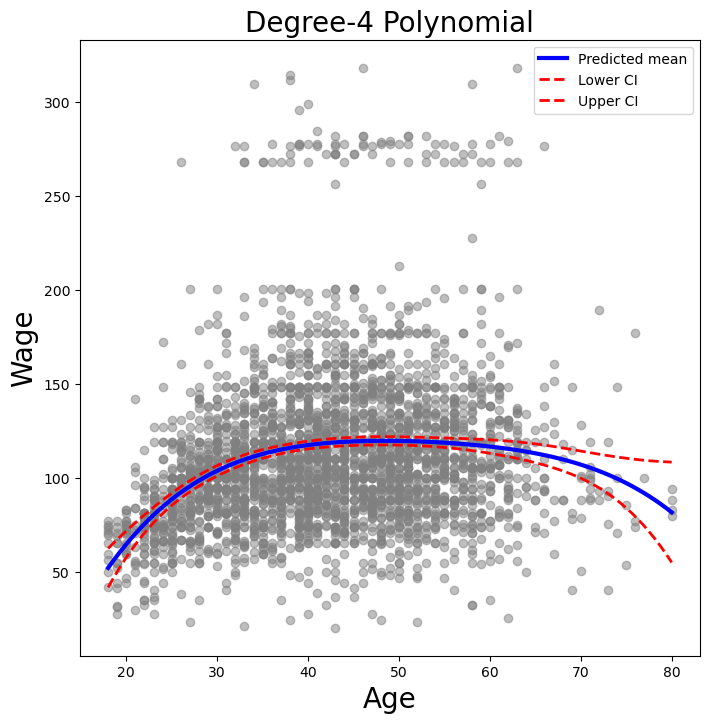

In [37]:
plot_wage_fit(age_df, poly_age, "Degree-4 Polynomial")

We see, that in the tails - confidence interval much bigger. This is natural effect of polynomial, since on those parts contains not much datapoints to estimate correctly 

In [40]:
models = [MS([poly("age", degree=d)]) for d in range(1, 6)]
Xs = [model.fit_transform(Wage) for model in models]
anova_lm(*[sm.OLS(y, X_).fit() for X_ in Xs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2998.0,5.022216e+06,0.0,NaN,NaN,NaN
1,2997.0,4.793430e+06,1.0,228786.010128,143.593107,2.363850e-32
2,2996.0,4.777674e+06,1.0,15755.693664,9.888756,1.679202e-03
3,2995.0,4.771604e+06,1.0,6070.152124,3.809813,5.104620e-02
4,2994.0,4.770322e+06,1.0,1282.563017,0.804976,3.696820e-01


In [42]:
summarize(poly_age_model)

,coef,std err,t,P>|t|
intercept,111.7036,0.729,153.283,0.000
"poly(age, degree=4)[0]",447.0679,39.915,11.201,0.000
"poly(age, degree=4)[1]",-478.3158,39.915,-11.983,0.000
"poly(age, degree=4)[2]",125.5217,39.915,3.145,0.002
"poly(age, degree=4)[3]",-77.9112,39.915,-1.952,0.051


In [46]:
models = [MS(["education", poly("age", degree=d)]) for d in range(1, 4)]
XEs = [model.fit_transform(Wage) for model in models]
anova_lm(*[sm.OLS(y, X_).fit() for X_ in XEs])

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,2997.0,3.902335e+06,0.0,NaN,NaN,NaN
1,2996.0,3.759472e+06,1.0,142862.701185,113.991883,3.838075e-26
2,2995.0,3.753546e+06,1.0,5926.207070,4.728593,2.974318e-02


In [52]:
X = poly_age.transform(Wage)
high_earn = Wage["high_earn"] = y > 250
glm = sm.GLM(high_earn, X, family=sm.families.Binomial())
B = glm.fit()
summarize(B)

,coef,std err,z,P>|z|
intercept,-4.3012,0.345,-12.457,0.000
"poly(age, degree=4)[0]",71.9642,26.133,2.754,0.006
"poly(age, degree=4)[1]",-85.7729,35.929,-2.387,0.017
"poly(age, degree=4)[2]",34.1626,19.697,1.734,0.083
"poly(age, degree=4)[3]",-47.4008,24.105,-1.966,0.049


In [54]:
newX = poly_age.transform(age_df)
preds = B.get_prediction(newX)
bands = preds.conf_int(alpha=0.05)

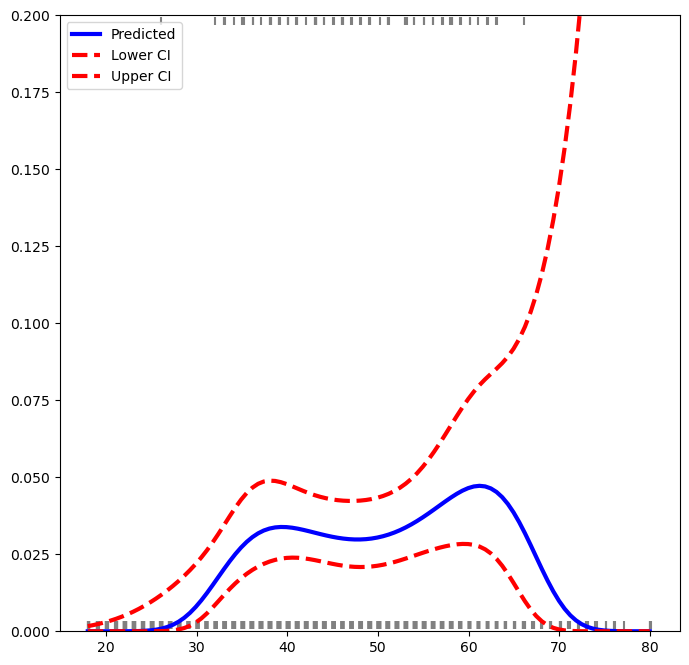

In [63]:
fig, ax = subplots(figsize=(8, 8))
rng = np.random.default_rng(0)
ax.scatter(age + 0.2 * rng.uniform(size=y.shape[0]),
           np.where(high_earn, 0.198, 0.002),
           fc="gray",
           marker="|")

ax.plot(age_df.values, preds.predicted_mean, "b", linewidth=3, label="Predicted")
ax.plot(age_df.values, bands[:, 0], "r--", linewidth=3, label="Lower CI")
ax.plot(age_df.values, bands[:, 1], "r--", linewidth=3, label="Upper CI")
ax.set_ylim([0, 0.2])

ax.legend()

We see, that in the tails we have a huge confidence interval since we are using 4-degree polynomial

In order to fit a step function, we need to discretize age, because step function works like this:
$$C_0(X) = I(X < c_1)$$
$$C_1(X) = I(c_1 \leq X < c_2)$$
$$C_2(X) = I(c_2 \leq X < c_3)$$
$$\vdots$$
$$C_K(X) = I(c_K \leq X)$$

In [68]:
cut_age = pd.qcut(age, 4)
cut_age.value_counts()

age
(42.0, 51.0]       817
(33.75, 42.0]      759
(17.999, 33.75]    750
(51.0, 80.0]       674
Name: count, dtype: int64

In [71]:
X_dummies = pd.get_dummies(cut_age)
X_dummies.head()

,"(17.999, 33.75]","(33.75, 42.0]","(42.0, 51.0]","(51.0, 80.0]"
0,True,False,False,False
1,True,False,False,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False


In [72]:
cut_age = pd.qcut(age, 4)
model = sm.OLS(y, X_dummies).fit()
summarize(model)

,coef,std err,t,P>|t|
"(17.999, 33.75]",94.1584,1.478,63.692,0.0
"(33.75, 42.0]",116.6608,1.470,79.385,0.0
"(42.0, 51.0]",119.1887,1.416,84.147,0.0
"(51.0, 80.0]",116.5717,1.559,74.751,0.0


In [77]:
age = np.linspace(age.min(), age.max(), 100)
age_cuts = pd.qcut(age, 4)
print(age_cuts.value_counts())
age_cuts_dummies = pd.get_dummies(age_cuts)
print(age_cuts_dummies.head())

(17.999, 33.5]    25
(33.5, 49.0]      25
(49.0, 64.5]      25
(64.5, 80.0]      25
Name: count, dtype: int64
   (17.999, 33.5]  (33.5, 49.0]  (49.0, 64.5]  (64.5, 80.0]
0            True         False         False         False
1            True         False         False         False
2            True         False         False         False
3            True         False         False         False
4            True         False         False         False


In [78]:
X_test = age_cuts_dummies
preds = model.get_prediction(X_test)
y_pred = preds.predicted_mean
bands = preds.conf_int(alpha=0.05)

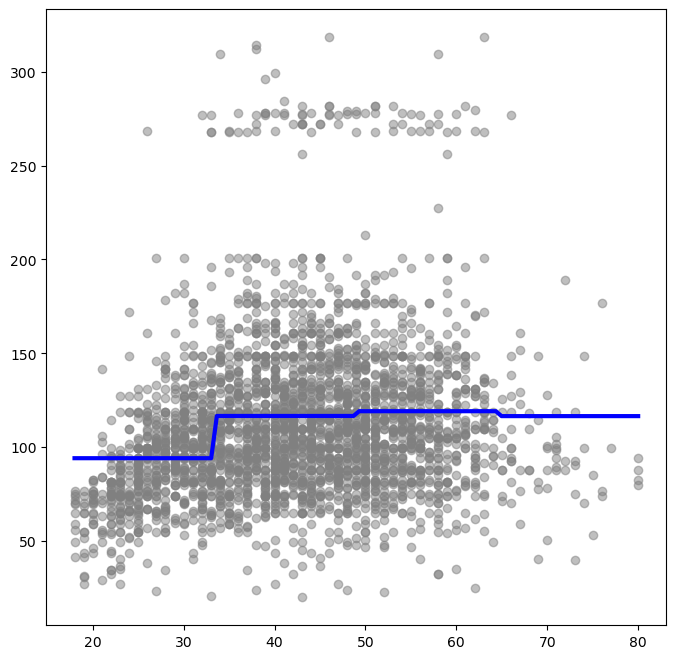

In [81]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(Wage["age"], Wage["wage"], alpha=0.5, fc="gray")
ax.plot(age, y_pred, "b", linewidth=3)

###  Splines

In [82]:
age = Wage["age"]

In [86]:
bs_ = BSpline(internal_knots=[25, 40, 60], intercept=True).fit(age)
bs_age = bs_.transform(age)
bs_age.shape

(3000, 7)

The **matrix produced by the B-spline transformation** contains the **evaluations of spline basis functions** for each data point.

Each **row** corresponds to one value of `age`,
and each **column** represents one **basis function** (a smooth curve active over a specific interval).

Values in a row show how strongly each basis function contributes to representing that age.
At any given age, only a few nearby basis functions have nonzero values, which ensures **local smoothness** and **flexible curve fitting**.

In [92]:
age.iloc[0:2]

0    18
1    24
Name: age, dtype: int64

In [91]:
bs_age.iloc[0:2]

,"BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[0]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[1]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[2]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[3]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[4]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[5]","BSpline(intercept=True, internal_knots=[25, 40, 60],\n lower_bound=np.float64(18.0), upper_bound=np.float64(80.0))[6]"
0,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.002915,0.559911,0.403778,0.033395,0.0,0.0,0.0


Above we see, that for `age` = 18 - first basis function is only activated since 18 is in the start, but for `age` = 24 - more functions are activated, while first does not since 24 is closer to middle

In [95]:
bs_age = MS([bs("age", internal_knots=[25, 40, 60], name="bs(age)")])
Xbs = bs_age.fit_transform(Wage)
model = sm.OLS(y, Xbs).fit()
summarize(model)

,coef,std err,t,P>|t|
intercept,60.4937,9.460,6.394,0.000
bs(age)[0],3.9805,12.538,0.317,0.751
bs(age)[1],44.6310,9.626,4.636,0.000
bs(age)[2],62.8388,10.755,5.843,0.000
bs(age)[3],55.9908,10.706,5.230,0.000
bs(age)[4],50.6881,14.402,3.520,0.000
bs(age)[5],16.6061,19.126,0.868,0.385


In [96]:
BSpline(df=6).fit(age).internal_knots_

array([33.75, 42.  , 51.  ])

In [98]:
BSpline(df=10).fit(age).internal_knots_

array([28.   , 33.75 , 38.   , 42.   , 46.375, 51.   , 56.   ])

In [99]:
bs_age0 = MS([bs('age', df=3, degree=0)]).fit(Wage)
Xbs0 = bs_age0.transform(Wage)
summarize(sm.OLS(y, Xbs0).fit())

,coef,std err,t,P>|t|
intercept,94.1584,1.478,63.687,0.0
"bs(age, df=3, degree=0)[0]",22.3490,2.152,10.388,0.0
"bs(age, df=3, degree=0)[1]",24.8076,2.044,12.137,0.0
"bs(age, df=3, degree=0)[2]",22.7814,2.087,10.917,0.0


In [101]:
natural_spline_age = MS([ns("age", df=5)]).fit(Wage)
M_ns = sm.OLS(y, natural_spline_age.transform(Wage)).fit()
summarize(M_ns)

,coef,std err,t,P>|t|
intercept,60.4752,4.708,12.844,0.000
"ns(age, df=5)[0]",61.5267,4.709,13.065,0.000
"ns(age, df=5)[1]",55.6912,5.717,9.741,0.000
"ns(age, df=5)[2]",46.8184,4.948,9.463,0.000
"ns(age, df=5)[3]",83.2036,11.918,6.982,0.000
"ns(age, df=5)[4]",6.8770,9.484,0.725,0.468


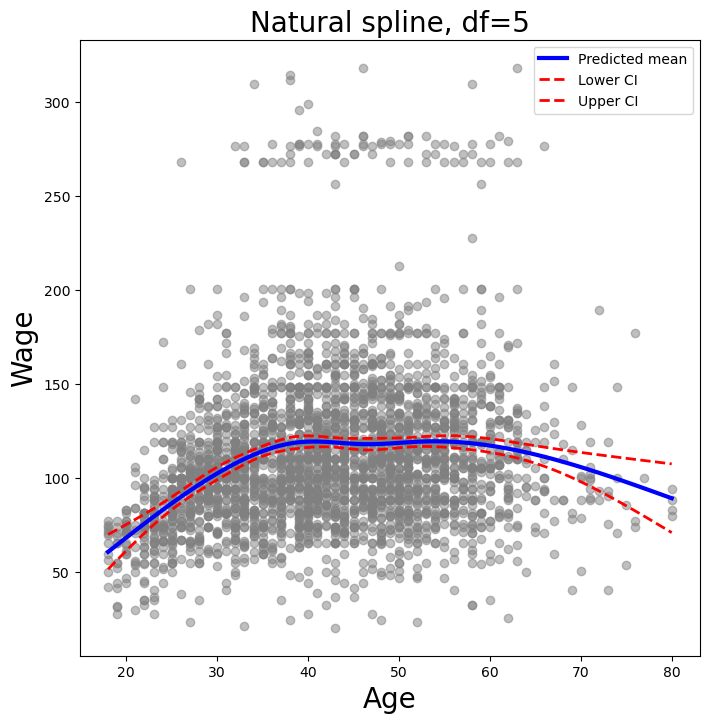

In [103]:
 plot_wage_fit(age_df, natural_spline_age, 'Natural spline, df=5')

We see, that the special ability of natural splines - linear ends to prevent those poor behavior of polynomials

### Smoothing Splines and GAMs

In [108]:
X_age = np.asarray(age).reshape((-1, 1))
X_age

array([[18],
       [24],
       [45],
       ...,
       [27],
       [27],
       [55]])

In [109]:
gam = LinearGAM(s_gam(0, lam=0.6))
gam.fit(X_age, y)

LinearGAM(callbacks=[Deviance(), Diffs()], fit_intercept=True, 
   max_iter=100, scale=None, terms=s(0) + intercept, tol=0.0001, 
   verbose=False)

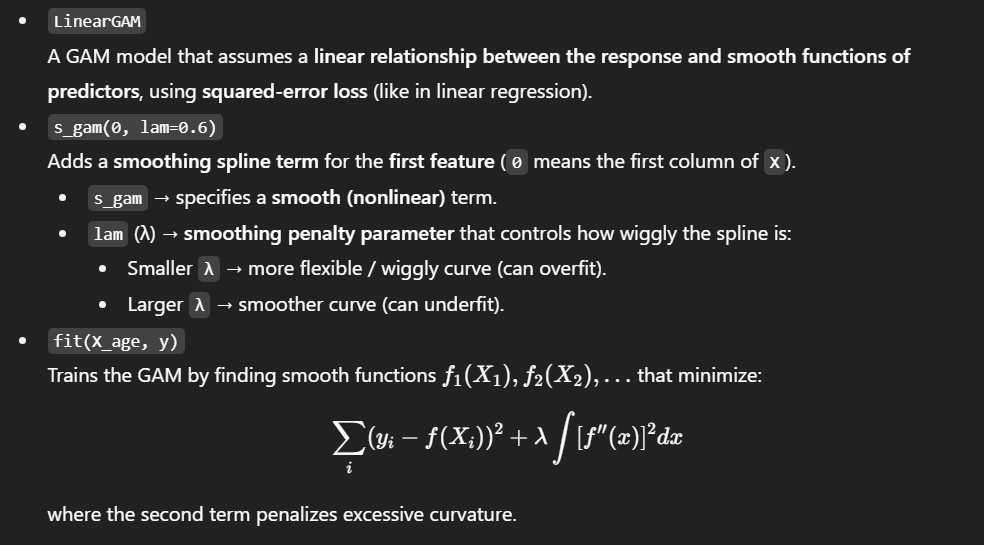

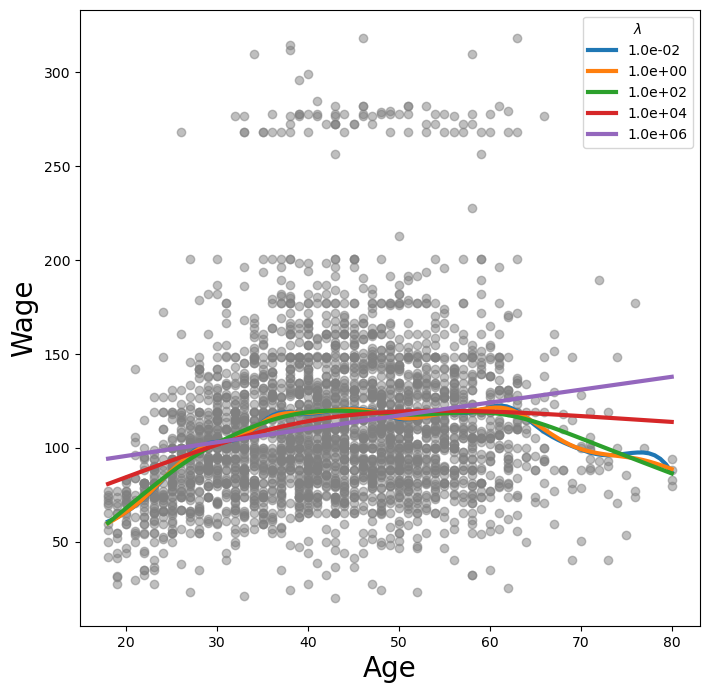

In [111]:
fig, ax = subplots(figsize=(8, 8))
ax.scatter(age, y, fc="gray", alpha=0.5)
for lam in np.logspace(-2, 6, 5):
  gam = LinearGAM(s_gam(0, lam=lam)).fit(X_age, y)
  ax.plot(age_grid,
          gam.predict(age_grid),
          label="{:.1e}".format(lam),
          linewidth=3)
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20)
ax.legend(title='$\lambda$')

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


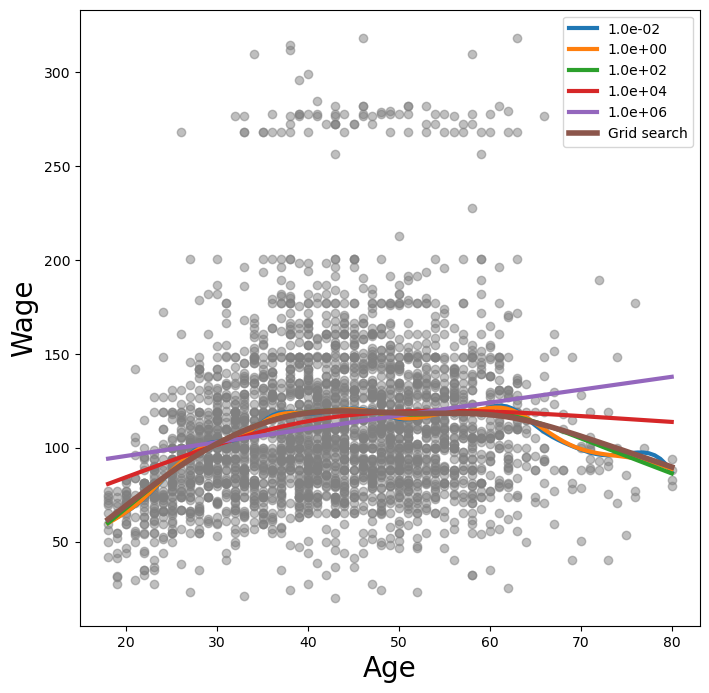

In [112]:
gam_opt = gam.gridsearch(X_age, y)
ax.plot(age_grid,
        gam_opt.predict(age_grid),
        label="Grid search",
        linewidth=4)
ax.legend()
fig

In [114]:
age_term = gam.terms[0]
lam_4 = approx_lam(X_age, age_term, 4)
age_term.lam = lam_4
degrees_of_freedom(X_age, age_term)

np.float64(4.0000001000025565)

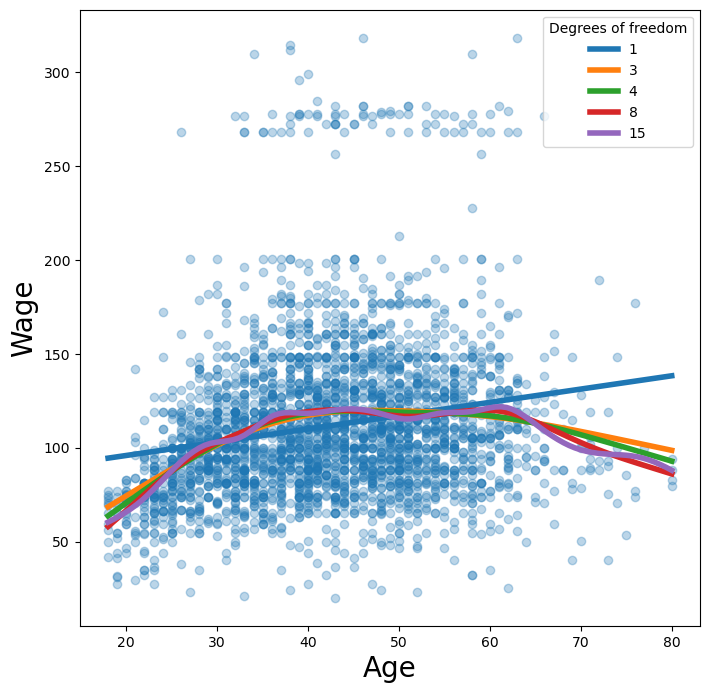

In [115]:
fig, ax = subplots(figsize=(8,8))
ax.scatter(X_age,
y,
alpha=0.3)
for df in [1,3,4,8,15]:
  lam = approx_lam(X_age, age_term, df+1)
  age_term.lam = lam
  gam.fit(X_age, y)
  ax.plot(age_grid,
          gam.predict(age_grid),
          label='{:d}'.format(df),
          linewidth=4)
  
ax.set_xlabel('Age', fontsize=20)
ax.set_ylabel('Wage', fontsize=20);
ax.legend(title='Degrees of freedom');

Additive Models with Several Terms

In [119]:
ns_age = NaturalSpline(df=4).fit(age)
ns_year = NaturalSpline(df=5).fit(Wage["year"])
Xs = [ns_age.transform(age),
      ns_year.transform(Wage["year"]),
      pd.get_dummies(Wage["education"]).values]
X_bh = np.hstack(Xs)
gam_bh = sm.OLS(y, X_bh).fit()

Above we denote:

* $y_i$ = response variable for observation $i$ (e.g., wage)
* $\text{age}_i$, $\text{year}_i$ = numeric predictors
* $edu_{i,j}$ = dummy variable for education category $j$
* $\beta_0$ = intercept, $\beta_j$ = coefficients for dummies
* $\varepsilon_i \sim N(0, \sigma^2)$ = error term

The semi-parametric regression model is:
$$
y_i = \beta_0 + f_{\text{age}}(\text{age}_i) + f_{\text{year}}(\text{year}_i) + \sum_j \beta_j \text{edu}_{i,j} + \varepsilon_i
$$

### Natural spline functions

Each smooth function is expressed as a linear combination of basis functions:
$$
f_{\text{age}}(\text{age}_i) = \sum_{k=1}^{K} \gamma_k B_k(\text{age}_i)
$$
$$
f_{\text{year}}(\text{year}_i) = \sum_{m=1}^{M} \delta_m C_m(\text{year}_i)
$$
Where:

* $B_k(\text{age})$, $C_m(\text{year})$ are natural spline basis functions.
* $K = 4$ and $M = 5$ correspond to degrees of freedom (df).
* Each basis function is non-zero only over a local interval, i.e., it is piecewise-defined.

For example, a B-spline basis ($B_k(\text{age})$) is active mainly when:
$$
c_{k} \le \text{age} \le c_{k+1}
$$
where $c_k$ are the knots.

Natural splines additionally impose linear boundary constraints at the edges, ensuring:
$$
f_{\text{age}}''(\text{age}_{\min}) = f_{\text{age}}''(\text{age}_{\max}) = 0
$$
This prevents extreme curvature at the boundaries, which stabilizes the extrapolation.

### Properties of natural splines

* **Piecewise polynomial:** Within each interval between knots, the spline is a cubic polynomial.
* **Smoothness:** Continuous first and second derivatives across knots.
* **Local support:** Each basis function affects the function only over a small interval $\rightarrow$ changing a coefficient ($\gamma_k$) only affects the curve locally.
* **Linear at boundaries:** Outside the range of the internal knots, the spline is linear, avoiding overfitting at the edges.

### Full expanded formula

Putting everything together:
$$
y_i = \beta_0 + \sum_{k=1}^{4} \gamma_k B_k(\text{age}_i) + \sum_{m=1}^{5} \delta_m C_m(\text{year}_i) + \sum_j \beta_j \text{edu}_{i,j} + \varepsilon_i
$$

* $B_k(\text{age}) \rightarrow$ natural spline basis for age (df=4)
* $C_m(\text{year}) \rightarrow$ natural spline basis for year (df=5)
* $\beta_j \rightarrow$ coefficients for categorical education
* $\varepsilon_i \sim N(0, \sigma^2)$

### Intuition

* Each numeric predictor is transformed into several spline basis functions $\rightarrow$ allows modeling nonlinear relationships.
* Categorical predictors are included linearly via dummies.
* The model remains linear in parameters, so standard regression estimation (OLS) can be used.
* Natural spline basis ensures smooth, stable curves with flexibility in the middle and linearity at the boundaries.

In [123]:
age_grid = np.linspace(age.min(), age.max(), 100) # test set for ages

In [131]:
print(X_bh) # train data
print("shape:", X_bh.shape)

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.01731602 -0.13795411  0.31872157 ...  0.          1.
   0.        ]
 [ 0.7510856   0.16605047  0.09131609 ...  1.          0.
   0.        ]
 ...
 [ 0.05844156 -0.18746615  0.43311146 ...  0.          0.
   0.        ]
 [ 0.05844156 -0.18746615  0.43311146 ...  1.          0.
   0.        ]
 [ 0.30656791  0.51156808  0.20710768 ...  0.          0.
   0.        ]]
shape: (3000, 14)


In [133]:
X_age_bh = X_bh.copy()[:100]
print(X_age_bh)
print("shape: ", X_age_bh.shape)

#so, we our goal is to create test set for age, keeping other fetures constant
#we sinply create a copy of train set and select only first 100 rows

[[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.01731602 -0.13795411  0.31872157 ...  0.          1.
   0.        ]
 [ 0.7510856   0.16605047  0.09131609 ...  1.          0.
   0.        ]
 ...
 [ 0.7510856   0.16605047  0.09131609 ...  0.          1.
   0.        ]
 [ 0.78017192  0.07222489  0.11002552 ...  0.          1.
   0.        ]
 [ 0.27056277 -0.20863018  0.48200765 ...  0.          1.
   0.        ]]
shape:  (100, 14)


In [142]:
X_bh[:].mean(0)
# this is just the mean of every column(because we want to keep some constant)

array([ 0.41104614,  0.10758615,  0.25528707, -0.10109003,  0.18140278,
        0.16459722,  0.09448982,  0.20326295,  0.02569167,  0.08933333,
        0.32366667,  0.21666667,  0.22833333,  0.142     ])

In [145]:
X_age_bh[:] = X_bh[:].mean(0)
X_age_bh

# now all columns are constant

array([[0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ],
       [0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ],
       [0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ],
       ...,
       [0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ],
       [0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ],
       [0.41104614, 0.10758615, 0.25528707, ..., 0.21666667, 0.22833333,
        0.142     ]])

In [147]:
X_age_bh[:, :4]
#below we see basis functions of natural spline for "age", and we want this columns to replace woth test data

array([[ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.10758615,  0.25528707, -0.10109003],
       [ 0.41104614,  0.

In [148]:
ns_age = NaturalSpline(df=4).fit(age)
X_age_bh[:, :4] = ns_age.transform(age_grid) #age_grid - test data

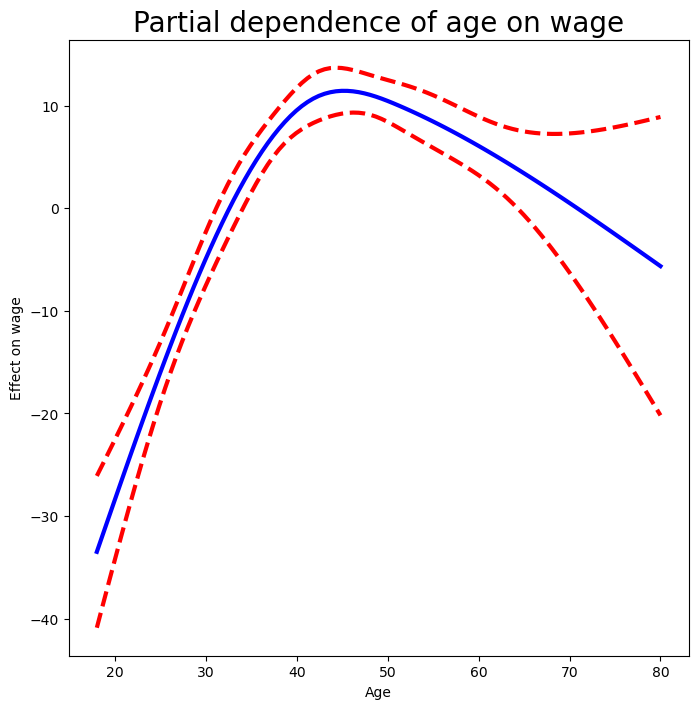

In [152]:
preds = gam_bh.get_prediction(X_age_bh)
bounds_age = preds.conf_int(alpha=0.05)
partial_age = preds.predicted_mean
# We center the partial effect so the plot shows how the variable itself affects the outcome 
# relative to its average, ignoring the overall level or intercept. This makes the effect of 
# age clear and easy to interpret.
center = partial_age.mean()
partial_age -= center
bounds_age -= center
####
fig, ax = subplots(figsize=(8,8))
ax.plot(age_grid, partial_age, 'b', linewidth=3)
ax.plot(age_grid, bounds_age[:,0], 'r--', linewidth=3)
ax.plot(age_grid, bounds_age[:,1], 'r--', linewidth=3)
ax.set_xlabel('Age')
ax.set_ylabel('Effect on wage')
ax.set_title('Partial dependence of age on wage', fontsize=20);